<a href="https://colab.research.google.com/github/RENSHUZHE/HKU-DQMC/blob/main/DQMC_Theory_2_Measurement_and_Updating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Nomenclature
The main derivations follows from these references

dos Santos, Introduction to Quantum Monte Carlo Simulations for Fermionic Systems, [article in Brazilian Journal of Physics, 33, 36 (2003)](https://arxiv.org/pdf/cond-mat/0303551).

Assaad and Evertz, World Line and Determinantal Quantum Monte Carlo Methods for Strongly Correlated Electron Systems, [book chapter in Computational Many-Particle Physics, Lecture Notes in Physics, 739, 277-356 (2008)](https://pawn.physik.uni-wuerzburg.de/~assaad/Reprints/assaad_evertz.pdf).



The following text and codes are prepared by Mr. [Shuzhe Ren](https://quantummc.xyz/renshuzhe/), Dr. [Gaopei Pan](https://scholar.google.com.hk/citations?user=vc75saMAAAAJ&hl=zh-CN) and [ZYM](https://quantummc.xyz/members/zi-yang-meng/).

# 1. Green's Function
We define the imaginary-time Green's function as follows:
$$\begin{array}{l}
G_{i j}(\tau, \tau)=\left\langle c_{i}(\tau) c_{j}^{\dagger}(\tau)\right\rangle, \qquad G_{i j}(\tau, 0)=\left\langle c_{i}(\tau) c_{j}^{\dagger}(0)\right\rangle,\\ G_{i j}(0, \tau)=\left\langle T_{\tau} c_{i}(0) c_{j}^{\dagger}(\tau)\right\rangle , G_{i j}(0,0)=\left\langle c_{i}(0) c_{j}^{\dagger}(0)\right\rangle
\end{array}$$
$T_\tau$ is the imaginary-time ordering operator, such that the later time operator is placed on the left. $$T_{\tau} \left[ c_{i}(\tau_{1}) c_{j}^{\dagger}(\tau_{2}) \right] = \theta(\tau_{1} - \tau_{2}) c_{i}(\tau_{1}) c_{j}^{\dagger}(\tau_{2}) - \theta(\tau_{2} - \tau_{1}) c_{j}^{\dagger}(\tau_{2}) c_{i}(\tau_{1})$$
Note that the definition of the Green's function in different places might differ from this one by a negative sign. (See [Introduction to Many-body Physics by Piers Coleman.](https://www.cambridge.org/core/books/introduction-to-manybody-physics/B7598FC1FCEE0285F5EC767E835854C8) )

If the Hamiltonian H is time-independent, the system remains in a steady state of thermal equilibrium. This means its observable properties do not depend on an absolute starting clock, only on the relative interval between events.

We can prove that $\langle c_i(\tau_1) c_j^\dagger(\tau_2) \rangle = \langle c_i(\tau_1 - \tau_2) c_j^\dagger(0) \rangle$. Hence, Green's Function $G_{i j}(\tau_1, \tau_2)$ only depends on $\tau_1-\tau_2$.  

We introduce the single-particle Green's function because it serves as one of the foundational building blocks for extracting many physical observables in many-body physics. For instance, one can easily obtain the local particle density $\langle \hat{n}_{i\sigma} \rangle = 1 - G_{ii}^\sigma(\tau, \tau)$ and the local magnetisation $\langle \hat{m}_i^z \rangle = \frac{1}{2}\left( G_{ii}^\downarrow(\tau, \tau) - G_{ii}^\uparrow(\tau, \tau) \right)$. Ordinarily, higher-order observables like the pair correlation $\langle c_{i\uparrow}^\dagger c_{j\downarrow}^\dagger c_{j\downarrow} c_{i\uparrow} \rangle$ involve four operators and cannot simply be reduced to two-point Green's functions. In the specific context of DQMC, however, the Hubbard-Stratonovich transformation decouples the interacting system into free fermions moving in a auxiliary field. Within any fixed auxiliary field configuration, the fermions are non-interacting, allowing us to seamlessly apply Wick's theorem to decompose higher-order correlations directly into products and sums of single-particle Green's functions.

# 2. Express Green's Function from the computable $B$ Matrix
Previously we have defined terms such as:
$$\mathbf{B}^{\uparrow}\left(l_{2} \Delta \tau, l_{1} \Delta \tau\right)=\prod_{l=l_{1}+1}^{l_{2}} e^{\alpha \operatorname{Diag}\left(\vec{S}_{l}\right)} e^{-\Delta \tau T}$$
For convenience, we define here the one with fermion operators:
$$\hat{\mathbf{U}}^{\uparrow}\left(l_{2} \Delta \tau, l_{1} \Delta \tau\right)=\prod_{l=l_{1}+1}^{l_{2}} e^{ \hat{\mathbf{c}}^{\dagger} \alpha \operatorname{Diag}\left(\vec{S}_{l}\right)\hat{\mathbf{c}}} e^{-\Delta \tau \hat{\mathbf{c}}^{\dagger}T\hat{\mathbf{c}}}$$

## 2.1 Observable average with auxilliary field

From the previous chapter, we know that the effective, unnormalised weight for a specific configuration $C$ of the auxiliary spacetime field is:
$$W_{C}=\prod_{\sigma=\uparrow\downarrow} \operatorname{Det}\left[\mathbf{I}+\mathbf{B}_{C}^{\sigma}\left(L_{\tau}\Delta\tau,(L_{\tau}-1)\Delta\tau\right) \cdots \mathbf{B}_{C}^{\sigma}(\Delta\tau,0)\right]=\prod_{\sigma=\uparrow\downarrow} \operatorname{Det}\left[\mathbf{I}+ \mathbf{B}_{C}^{\sigma}(\beta,0)\right] =\operatorname{Det}\left[\mathbf{I}+ \mathbf{B}_{C}(\beta,0)\right]$$

Because the various matrices are block-diagonal with respect to spin, we can evaluate the spin-up and spin-down cases separately, multiplying their respective weights together at the end. (Consequently, for notational simplicity, the spin index $\sigma$ is suppressed in the following equations, writing $\mathbf{B}^{\sigma}$ simply as $\mathbf{B}$.)

This effective weight $W_C$ is exactly the numerator required to define the configuration probability $\mathrm{P}_{C}$. By normalising $W_C$ over all possible field configurations, we obtain the true probability distribution for the auxiliary field $C$:

$$\mathrm{P}_{C} = \frac{W_C}{\sum_{C'} W_{C'}} = \frac{ \operatorname{Det}\left[\mathbf{I}+ \mathbf{B}_{C}(\beta, 0)\right]}{\sum_{C'} \operatorname{Det}\left[\mathbf{I}+ \mathbf{B}_{C'}(\beta, 0)\right]}$$

With this probability distribution strictly established, we can rewrite the expectation value of any physical observable. In the Matsubara formalism, we are often interested in the expectation value of an operator $\hat{O}$ evaluated at a specific imaginary time $\tau$, denoted as $\hat{O}(\tau)$. The imaginary time variable dictates exactly where the measurement is inserted during the thermal evolution of the system, with $\tau$ ranging from $0$ to $\beta$.

What begins as a standard quantum mechanical trace for an observable at imaginary time $\tau$:

$$\langle \hat{O}(\tau) \rangle = \frac{\operatorname{Tr}\left[e^{-(\beta-\tau) \hat{H}} \hat{O} e^{-\tau \hat{H}}\right]}{Z}$$

is transformed into a classical statistical sum over the auxiliary field configurations, weighted by $\mathrm{P}_{C}$:

$$\langle \hat{O}(\tau) \rangle = \sum_{C} \mathrm{P}_{C}\langle \hat{O}(\tau)\rangle_{C}+O\left(\Delta\tau^{2}\right)$$

where $\langle \hat{O}(\tau) \rangle_{C}$ is the expectation value of the operator evaluated within a single, fixed background configuration $C$. It takes the specific form:

$$\langle\hat{O}(\tau)\rangle_{C}=\frac{\operatorname{Tr}\left[\hat{\mathbf{U}}_{C}(\beta, \tau) \hat{O} \hat{\mathbf{U}}_{C}(\tau, 0)\right]}{\operatorname{Tr}\left[\hat{\mathbf{U}}_{C}(\beta, 0)\right]}$$


Therefore, the numerator $\operatorname{Tr}\left[\hat{\mathbf{U}}_{C}(\beta, \tau) \hat{O} \hat{\mathbf{U}}_{C}(\tau, 0)\right]$ represents the weight of the states after evolving up to $\tau$ within the specific background $C$, acting with $\hat{O}$, and evolving the rest of the way. The denominator $\operatorname{Tr}\left[\hat{\mathbf{U}}_{C}(\beta, 0)\right]$ is the partition function strictly for the configuration $C$, which is necessary to properly normalise the probability of all states within this frozen background.






## 2.2 Equal-time Green's Function
Suppose a one-body operator can be expressed as $\hat{O}=\hat{\mathbf{c}}^{\dagger} O \hat{\mathbf{c}}$. (*Note that not all quadratic operators can be written in this specific form; for instance, $\hat{c}_{i} \hat{c}_{j}^{\dagger}$ cannot.*) We can then employ a useful maths trick:
$$\begin{aligned}
\langle\hat{O}\rangle_{\mathcal{C}} &=\left.\frac{\partial}{\partial \eta} \ln \operatorname{Tr}\left[\hat{U}_{\mathcal{C}}(\beta, \tau) e^{\eta \hat{O}} \hat{U}_{\mathcal{C}}(\tau, 0)\right]\right|_{\eta=0} \,\,\,(\text{Verify this Yourself!})\\
&=\left.\frac{\partial}{\partial \eta} \ln \operatorname{Det}\left[\mathbf{1}+B_{\mathcal{C}}(\beta, \tau) e^{\eta O} B_{\mathcal{C}}(\tau, 0)\right]\right|_{\eta=0} \\
&=\left.\frac{\partial}{\partial \eta} \operatorname{Tr} \ln \left[\mathbf{1}+B_{\mathcal{C}}(\beta, \tau) e^{\eta O} B_{\mathcal{C}}(\tau, 0)\right]\right|_{\eta=0} \\
&=\operatorname{Tr}\left[B_{\mathcal{C}}(\tau, 0)\left(1+B_{\mathcal{C}}(\beta, 0)\right)^{-1} B_{\mathcal{C}}(\beta, \tau) O\right] (\text{Trace Cyclicity}) \\
&=\operatorname{Tr}\left[\left(1-\left(1+B_{\mathcal{C}}(\tau, 0) B_{\mathcal{C}}(\beta, \tau)\right)^{-1}\right) O\right]
\end{aligned}$$
The final step relies on the Sherman-Morrison formula:
$$\mathbf{U}\left(\mathbf{I}_{k}+\mathbf{V U}\right)^{-1} \mathbf{V} =\mathbf{I}-(\mathbf{I}+\mathbf{U V})^{-1}$$
where $\mathbf{U}$ is an $N \times k$ matrix and $\mathbf{V}$ is a $k \times N$ matrix. A proof of this identity is provided in the **appendix**.

To evaluate the equal-time Green's function $\left\langle\hat{c}_{i} \hat{c}_{j}^{\dagger}\right\rangle$, we first rewrite the operator as $\hat{O}=\delta_{i j}-\hat{c}_{j}^{\dagger} \hat{c}_{i}$. The term $\hat{c}_{j}^{\dagger} \hat{c}_{i}$ has a straightforward matrix representation $O_{lm} = \delta_{im}\delta_{jl}$. Substituting this into our previous result yields:
$$\langle\hat{c}_{j}^{\dagger} \hat{c}_{i}\rangle_{C} = \operatorname{Tr}\left[\left(1-\left(1+B_{\mathcal{C}}(\tau, 0) B_{\mathcal{C}}(\beta, \tau)\right)^{-1}\right) O\right]= \left[ \mathbf{1}-\left(\mathbf{1}+B_{C}(\tau, 0) B_{C}(\beta, \tau)\right)^{-1} \right]_{ij} = \delta_{ij} - \left[ \left(\mathbf{1}+B_{C}(\tau, 0) B_{C}(\beta, \tau)\right)^{-1} \right]_{ij}$$

At this stage, it is crucial to clearly distinguish between the true physical Green's function $G(\tau, \tau)$ and the configuration-specific Green's function $G_C(\tau, \tau)$. The true physical expectation value is the ensemble average over all possible auxiliary field configurations, such that $G(\tau, \tau) = \langle G_C(\tau, \tau) \rangle$. However, for the sake of convenience in the following derivations and algorithmic discussions, we will refer to the configuration-specific Green's function $G_C$ simply as the "Green's function".

$$G_{ij}(\tau, \tau)_{C} = \left\langle\hat{c}_{i} \hat{c}_{j}^{\dagger}\right\rangle_{C} = \langle\delta_{ij} - \hat{c}_{j}^{\dagger} \hat{c}_{i}\rangle_{C} = \delta_{ij} - \langle\hat{c}_{j}^{\dagger} \hat{c}_{i}\rangle_{C} =[\mathbf{1}+B(\tau, 0) B(\beta, \tau)]^{-1}_{ij}$$

As a useful aside, we can exploit the matrix identity $A B^{-1} C= \left(C^{-1} B A^{-1}\right)^{-1}$. Applying this to the definition of the equal-time Green's function reveals a neat relationship:
$$B_{C}\left(\tau_{1}, \tau_{2}\right) G_{C}\left(\tau_{2}, \tau_{2}\right) B_{C}^{-1}\left(\tau_{1}, \tau_{2}\right)=G_{C}\left(\tau_{1}, \tau_{1}\right)$$

In computational practice, this relation is useful because updating the Green's function via matrix multiplication can be more efficient and stable than repeatedly calculating full matrix inversions.

## 2.3 Unequal-time Green's Function
Next, we turn our attention to the unequal-time Green's function, defined as:
$$G_{C}\left(\tau_{1}, \tau_{2}\right)_{i, j}=\left\langle T c_{i}\left(\tau_{1}\right) c_{j}^{\dagger}\left(\tau_{2}\right)\right\rangle_{C}=\left\{\begin{array}{c}
\left\langle c_{i}\left(\tau_{1}\right) c_{j}^{\dagger}\left(\tau_{2}\right)\right\rangle_{C} \text { if } \tau_{1} \geq \tau_{2} \\
-\left\langle c_{j}^{\dagger}\left(\tau_{2}\right) c_{i}\left(\tau_{1}\right)\right\rangle_{C} \text { if } \tau_{1}<\tau_{2}
\end{array}\right.$$

To evaluate this, it is helpful to establish a standard quantum mechanics result. Consider the time-evolved operator:
$$c_i(\tau)=e^{\tau \mathbf{c}^{\dagger} A c} c_{i} e^{-\tau c^{\dagger} A c}$$
Taking the first derivative with respect to $\tau$ yields:
$$\frac{\partial c_i(\tau)}{\partial \tau}=e^{\tau c^{\dagger} A c}\left[\boldsymbol{c}^{\dagger} A \boldsymbol{c}, c_{i}\right] e^{-\tau \boldsymbol{c}^{\dagger} A \boldsymbol{c}}=-\sum_{k} A_{i, k} c_{k}(\tau)$$
Following this logic, we can readily deduce the higher-order derivatives. This allows us to express the operator using a Taylor expansion:
$$c_i(\tau)=c_i - \tau \left(A\boldsymbol{c}(\tau)\right)_i + \tau^2 \left(A^2\boldsymbol{c}(\tau)\right)_i+ \cdots = \left(e^{-\tau A} c\right)_{i}$$
Setting $\tau=1$ simplifies this to:
$$e^{ c^{\dagger} A c} c_{i} e^{- c^{\dagger} A c}=\left(e^{-A} c\right)_{i}$$
By applying a similar procedure to the creation operator, we obtain:
$$e^{ c^{\dagger} A c} c^{\dagger}_{i} e^{- c^{\dagger} A c}=\left(\boldsymbol{c}^{\dagger} e^{A}\right)_{i}$$
These identities allow us to evaluate the similarity transformations of our operators:
$$\begin{array}{l}
U_{C}^{-1}\left(\tau_{1}, \tau_{2}\right) c_{i} U_{C}\left(\tau_{1}, \tau_{2}\right)=\left(B_{C}\left(\tau_{1}, \tau_{2}\right) c\right)_{i} \\
U_{C}^{-1}\left(\tau_{1}, \tau_{2}\right) c_{i}^{\dagger} U_{C}\left(\tau_{1}, \tau_{2}\right)=\left(c^{\dagger} B_{C}^{-1}\left(\tau_{1}, \tau_{2}\right)\right)_{i}
\end{array}$$
Substituting these back into the expectation value gives the result for $\tau_{1}>\tau_{2}$:
$$\begin{aligned}
\left\langle c_{i}\left(\tau_{1}\right) c_{j}^{\dagger}\left(\tau_{2}\right)\right\rangle_{C} &=\frac{\operatorname{Tr}\left[U_{C}\left(\beta, \tau_{1}\right) c_{i} U_{C}\left(\tau_{1}, \tau_{2}\right) c_{j}^{\dagger} U_{C}\left(\tau_{2}, 0\right)\right]}{\operatorname{Tr}\left[U_{C}(\beta, 0)\right]} \\
&=\frac{\operatorname{Tr}\left[U_{C}\left(\beta, \tau_{2}\right) U_{C}^{-1}\left(\tau_{1}, \tau_{2}\right) c_{i} U_{C}\left(\tau_{1}, \tau_{2}\right) c_{j}^{\dagger} U_{C}\left(\tau_{2}, 0\right)\right]}{\operatorname{Tr}\left[U_{C}(\beta, 0)\right]}\\
&=\sum_k B_{C}\left(\tau_{1}, \tau_{2}\right)_{ik} \frac{\operatorname{Tr}\left[ U_{C}\left(\beta, \tau_{2}\right) c_{k} c_{j}^{\dagger} U_{C}\left(\tau_{2}, 0\right) \right]}{\operatorname{Tr}\left[U_{C}(\beta, 0)\right]}\\
&=\left[B_{C}\left(\tau_{1}, \tau_{2}\right) G_{C}\left(\tau_{2}, \tau_{2}\right)\right]_{i, j}
\end{aligned}$$
By applying an analogous approach for the case where $\tau_{2}>\tau_{1}$, we find:
$$G_{C}\left(\tau_{1}, \tau_{2}\right)_{i, j}=-\left\langle c_{j}^{\dagger}\left(\tau_{2}\right) c_{i}\left(\tau_{1}\right)\right\rangle_{C}=-\left[\left(1-G_{C}\left(\tau_{1}, \tau_{1}\right)\right) B_{C}^{-1}\left(\tau_{2}, \tau_{1}\right)\right]_{i, j} \tag{2.3.1}$$
Finally, when dealing with more complex physical quantities, such as the four-point function $\left\langle c_{i}^{\dagger}\left(\tau_{1}\right) c_{i}\left(\tau_{1}\right) c_{j}^{\dagger}\left(\tau_{2}\right) c_{j}\left(\tau_{2}\right)\right\rangle$, we can invoke Wick's theorem. This theorem is powerful because it allows us to decompose these higher-order expectation values into simple sums and differences of products of the two-point Green's functions we have just derived.

# 3. Algorithm Updating

## 3.1 Acceptance Probability
We know that the weight $W_c$ corresponding to a certain auxiliary field configuration is $\operatorname{det}[\mathbf{I}+\mathbf{B}(\beta, \tau) \mathbf{B}(\tau, 0)]$, and the weight $W_c'$ after updating the auxiliary field of the $\tau$ slice ($\tau =l \Delta \tau$) is :
$$\begin{aligned}
W'_c=& \operatorname{det}[\mathbf{I}+\mathbf{B}(\beta, \tau) e^{V\left(\vec{S}^{\prime}_{l}\right)} e^{-\Delta \tau T} \mathbf{B}(\tau -\Delta \tau, 0)]\\
= & \operatorname{det}[\mathbf{I}+\mathbf{B}(\beta, \tau) e^{V\left(\vec{S}^{\prime}_{l}\right)} e^{-V\left(\vec{S}_{l}\right)} \mathbf{B}(\tau , 0)]\\
=&\operatorname{det}[\mathbf{I}+\mathbf{B}(\beta, \tau) (\mathbf{I}+\mathbf{\Delta}) \mathbf{B}(\tau , 0)]
\end{aligned}$$
Where $\mathbf{\Delta}=e^{V\left(\vec{S}^{\prime}_{l}\right)} e^{-V\left(\vec{S}_{l}\right)}-\mathbf{I}$. We notice that, for forms of on-site interactions such as the Hubbard model, the potential matrix $V(\vec{S}_l)= \pm \alpha \operatorname{Diag}(\vec{S}_l)$. Because $V(\vec{S}^{\prime}_{l})$ and $V(\vec{S}_{l})$ are both diagonal matrices, they commute. This mathematically guarantees that $e^{V(\vec{S}^{\prime}_{l})} e^{-V(\vec{S}_{l})} = e^{V(\vec{S}^{\prime}_{l}) - V(\vec{S}_{l})}$, allowing us to simplify the perturbation matrix to $\mathbf{\Delta}=e^{V\left(\vec{S}^{\prime}_{l}\right)-V\left(\vec{S}_{l}\right)} -\mathbf{I}$.

When changing the value of the auxiliary field $s_{i,l}$ of one site in $L \times L \times L_{\tau}$, the $\mathbf{\Delta}$ matrix has only one non-zero element, which is $e^{\pm \alpha \Delta s_{i,l}}-1$. The $\pm$ corresponds to spin up and down.
Therefore, when we calculate the acceptance probability (the ratio of weights) before and after the update, we have:
$$\begin{aligned}
& \frac{\operatorname{det}[\mathbf{I}+\mathbf{B}(\beta, \tau)(\mathbf{I}+\Delta) \mathbf{B}(\tau, 0)]}{\operatorname{det}[\mathbf{I}+\mathbf{B}(\beta, \tau) \mathbf{B}(\tau, 0)]} \\
=& \frac{\operatorname{det}[\mathbf{I}+\mathbf{B}(\beta, 0)+\mathbf{B}(\beta, \tau) \Delta \mathbf{B}(\tau, 0)]}{\operatorname{det}[\mathbf{I}+\mathbf{B}(\beta, 0)]} \\
=& \operatorname{det}\left[\mathbf{I}+\mathbf{B}(\beta, \tau) \Delta \mathbf{B}(\tau, 0)(\mathbf{I}+\mathbf{B}(\beta, 0))^{-1}\right] \\
=& \operatorname{det}\left[\mathbf{I}+\Delta \mathbf{B}(\tau, 0)(\mathbf{I}+\mathbf{B}(\beta, 0))^{-1} \mathbf{B}(\beta, \tau)\right] \\
=& \operatorname{det}\left[\mathbf{I}+\boldsymbol{\Delta}\left(\mathbf{I}-(\mathbf{I}+\mathbf{B}(\tau, 0) \mathbf{B}(\beta, \tau))^{-1}\right)\right] \\
=& \operatorname{det}[\mathbf{I}+\mathbf{\Delta}(\mathbf{I}-\mathbf{G}_C(\tau, \tau))]
\end{aligned}$$
Where the 3rd equality uses the **Sylvester's Determinant Identity** in the **Appendix**, the 4th equality uses the Sherman-Morrison formula:
$$(\mathbf{I}+\mathbf{U V})^{-1}=\mathbf{I}-\mathbf{U}\left(\mathbf{I}_{k}+\mathbf{V U}\right)^{-1} \mathbf{V}$$
$\mathbf{U}$ is an $N \times k$ matrix, and $\mathbf{V}$ is a $k \times N$ matrix. See the appendix for the proof.
Because the $\mathbf{\Delta}$ matrix here has only one non-zero element, the acceptance probability can actually be simply calculated in the following way:
$$
\begin{aligned}
r=&\operatorname{det}[\mathbf{I}_{N \times N}+\mathbf{\Delta}_{N \times N}(\mathbf{I}-\mathbf{G}_C(\tau, \tau))_{N \times N}] \\
=& \operatorname{det}[\mathbf{I}_{N \times N}+\mathbf{\Delta}_{N \times 1}(\mathbf{I}-\mathbf{G}_C(\tau, \tau))_{1 \times N}] \,\,\, (\text{only 1 non-zero entry})\\
=& \operatorname{det}[\mathbf{I}_{1 \times 1}+(\mathbf{I}-\mathbf{G}_C(\tau, \tau))_{1 \times N} \mathbf{\Delta}_{N \times 1}] \,\,\, (\text{Sylvester's Determinant Identity})\\
=& \operatorname{det}[\mathbf{I}_{1 \times 1}+(\mathbf{I}-\mathbf{G}_C(\tau, \tau))_{1 \times 1} \mathbf{\Delta}_{1 \times 1}] \,\,\, (\text{only 1 non-zero entry}) \\
=& 1+\mathbf{\Delta}_{i i}\left(1-\mathbf{G}_{C, i i}\right)
\end{aligned} \tag{3.1.1}
$$

For example, the weight ratio for the spin up part is $1+(e^{\alpha \Delta s_{i,l}}-1)(1-G_C^{\uparrow}(\tau,\tau)_{i,i})$, and for the spin down part it is $1+(e^{-\alpha \Delta s_{i,l}}-1)(1-G_C^{\downarrow}(\tau,\tau)_{i,i})$. We see that, due to the special form of the Hubbard model, when we have the value of the corresponding equal-time Green's function, we do not need to calculate the multiplication of a massive matrix plus the determinant; we only need to calculate a single number to obtain the acceptance probability.
This mathematically collapses the $\mathcal{O}(N^3)$ determinant ratio into a remarkably simple $\mathcal{O}(1)$ scalar calculation: $r = 1+\mathbf{\Delta}_{ii}\left(1-\mathbf{G}_{C, ii}\right)$.

# 3.2 Updating the Equal-Time Green's Function (The Rank-1 Update)
If the proposed spin flip is accepted, the Green's function $\mathbf{G}_C(\tau, \tau)$ must be updated to reflect the new auxiliary field configuration.

Similar to derivation in Sec 3.1, the new updated Green's function is defined as:
$$\begin{aligned}
\mathbf{G}^{\prime}_C(\tau, \tau) &=[\mathbf{I}+(\mathbf{I}+\boldsymbol{\Delta}) \mathbf{B}(\tau, 0) \mathbf{B}(\beta, \tau)]^{-1} \\
&=\mathbf{G}_C(\tau, \tau)[(\mathbf{I}+(\mathbf{I}+\boldsymbol{\Delta}) \mathbf{B}(\tau, 0) \mathbf{B}(\beta, \tau)) \mathbf{G}_C(\tau, \tau)]^{-1} \\
&=\mathbf{G}_C(\tau, \tau)\left[\left(\mathbf{I}+(\mathbf{I}+\boldsymbol{\Delta})\left(\mathbf{G}_C^{-1}(\tau, \tau)-\mathbf{I}\right)\right) \mathbf{G}_C(\tau, \tau)\right]^{-1} \,\,\, (\text{Def of } \mathbf{G}_C)\\
&=\mathbf{G}_C[\mathbf{I}+\boldsymbol{\Delta}(\mathbf{I}-\mathbf{G}_C)]^{-1} \,\,\, (\text{Sherman-Morrison formula})
\end{aligned}$$

We have:
$$\begin{aligned}
\mathbf{G}^{\prime}_C(\tau, \tau) &=\mathbf{G}_{C, N \times N}(\mathbf{I}_{N \times N}+\boldsymbol{\Delta}_{N \times N} (\mathbf{I}-\mathbf{G}_C)_{N \times N})^{-1} \\
&=\mathbf{G}_{C, N \times N}(\mathbf{I}_{N \times N}+\boldsymbol{\Delta}_{N \times 1} (\mathbf{I}-\mathbf{G}_C)_{1 \times N})^{-1} \\
&\left.=\mathbf{G}_{C, N \times N}\left[\mathbf{I}_{N \times N}-\boldsymbol{\Delta}_{N \times 1}\left(\mathbf{I}_{1 \times 1}+(\mathbf{I}-\mathbf{G}_C)_{1 \times N} \boldsymbol{\Delta}_{N \times 1}\right)^{-1} (\mathbf{I}-\mathbf{G}_C)_{1 \times N}\right)\right] \,\,\, (\text{Sherman-Morrison Formula}) \\
&=\mathbf{G}_{C, N \times N}-\mathbf{G}_{C, N \times N} \boldsymbol{\Delta}_{N \times 1} \; \frac{1}{r}\; (\mathbf{I}-\mathbf{G}_C)_{1 \times N} \,\,\,(\text{Eqn 3.1.1}) \\
&=\mathbf{G}_{C, N \times N}-\mathbf{G}_{C, N \times 1} \boldsymbol{\Delta}_{1 \times 1} \; \frac{1}{r}\; (\mathbf{I}-\mathbf{G}_C)_{1 \times N}\\
&=\mathbf{G}_{C, N \times N}-\mathbf{G}_C(:,i) \boldsymbol{\Delta}_{ii} \; \frac{1}{r}\; (\mathbf{I}-\mathbf{G}_C)(i,:)
\end{aligned}$$

This trick reduces the state update cost from $\mathcal{O}(N^3)$ down to $\mathcal{O}(N^2)$.

## 3.3 Imaginary Time Propagation (The Wrapping Technique)
After finishing the update of the auxiliary field for a certain imaginary time slice, we turn to attempting to update the auxiliary field for the next slice. At this time, we will obtain the Green's function at the new imaginary time position. From Eqn (2.3.1) we know:
$$\mathbf{G}_C(\tau+\Delta \tau, \tau+\Delta \tau)=\mathbf{B}(\tau+\Delta \tau, \tau) \mathbf{G'}_C(\tau, \tau) \mathbf{B}^{-1}(\tau+\Delta \tau, \tau)$$
Similarly, we have backward wrapping:
$$\mathbf{G}_C(\tau-\Delta \tau, \tau-\Delta \tau)=\mathbf{B}^{-1}(\tau, \tau-\Delta \tau) \mathbf{G'}_C(\tau, \tau) \mathbf{B}(\tau, \tau -\Delta \tau)$$


# 4. Global Monte Carlo Flow Structure
1. **The Forward Sweep Initiation**
The algorithm begins its global sweep by marching sequentially through the imaginary time axis, starting from slice $\tau = 1$ and advancing towards $L_\tau$.

2. **Local Spatial Updates**
At each fixed imaginary time slice $\tau$, the algorithm sweeps across all spatial sites. It attempts local updates to the auxiliary field at each site, updating the Green's function $\mathbf{G}_C(\tau, \tau)$ upon every accepted flip (as detailed in Subsections 3.1 & 3.2).

3. **Temporal Wrapping**
Once the spatial sweep for the current slice $\tau$ is complete, the fully updated Green's function is wrapped forward to the next imaginary time slice (as detailed in Subsection 3.3). Steps 2 and 3 are repeated consecutively until the algorithm reaches the final slice, $L_\tau$.

4. **The Reverse Sweep**
After completing the forward sweep, the process immediately reverses direction. The algorithm sweeps backwards from $L_\tau$ down to $1$, performing the same local spatial updates but wrapping the Green's function backwards in imaginary time. This symmetric forward-and-backward structure ensures the macroscopic Markov chain is reversible.

# 5. Code Realisation on 1D Hubbard Model

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def get_matrix_exponential(matrix):
    """
    Computes matrix exponential using eigendecomposition
    to avoid relying on external libraries.
    """
    eigenvalues, eigenvectors = np.linalg.eig(matrix)
    return eigenvectors @ np.diag(np.exp(eigenvalues)) @ np.linalg.inv(eigenvectors)

$$\langle n_i \rangle = \langle n_{i\uparrow} \rangle + \langle n_{i\downarrow} \rangle = (1 - G^{\uparrow}_{ii}) + (1 - G^{\downarrow}_{ii})$$

The double occupancy measures how often two electrons share the same site. Because the Hubbard-Stratonovich transformation decouples the spins into a non-interacting system within a fixed auxiliary field, you can use Wick's theorem to calculate this simply as the product of the individual spin densities.
$$\langle n_{i\uparrow} n_{i\downarrow} \rangle = \langle n_{i\uparrow} \rangle \langle n_{i\downarrow} \rangle = (1 - G^{\uparrow}_{ii})(1 - G^{\downarrow}_{ii})$$


The kinetic energy is derived from the off-diagonal elements of the Green's function, corresponding to the nearest-neighbour hopping terms.$$\langle K \rangle = -t \sum_{\langle i,j \rangle, \sigma} \langle c^\dagger_{i\sigma} c_{j\sigma} \rangle = -t \sum_{\langle i,j \rangle, \sigma} G^\sigma_{ji}$$

In [8]:
def run_dqmc_sweeps(N_sites, L_tau, S, alpha, t, G_up, G_dn, compute_B_matrix, warmup_sweeps=20, measurement_sweeps=50):
    """
    Executes the thermalisation and measurement sweeps for a DQMC simulation
    of the Hubbard model. It performs local spatial updates and temporal wrapping,
    updating the auxiliary field S and the Green's functions in place.

    Args:
        N_sites (int): Number of spatial lattice sites.
        L_tau (int): Number of imaginary time slices.
        S (ndarray): Auxiliary Ising field matrix of shape (N_sites, L_tau).
        alpha (float): Hubbard-Stratonovich scaling parameter.
        G_up (ndarray): Spin-up equal-time Green's function.
        G_dn (ndarray): Spin-down equal-time Green's function.
        compute_B_matrix (callable): Function taking (l, sigma, S) to compute the B matrix.
        warmup_sweeps (int): Number of initial sweeps to equilibrate the Markov chain.
        measurement_sweeps (int): Number of subsequent sweeps for data collection.

    Returns:
        tuple: (avg_density, avg_double_occ) over the measurement sweeps.
    """

    # --- Warm-up Phase (Thermalisation) ---
    for sweep in range(warmup_sweeps):
        # Perform forward sweep (no measurements)
        for l in range(L_tau):
            for i in range(N_sites):
                s_old = S[i, l]
                s_new = -s_old

                delta_S = s_new - s_old
                Delta_ii_up = np.exp(alpha * delta_S) - 1.0
                Delta_ii_dn = np.exp(-alpha * delta_S) - 1.0

                r_up = 1.0 + Delta_ii_up * (1.0 - G_up[i, i])
                r_dn = 1.0 + Delta_ii_dn * (1.0 - G_dn[i, i])
                r = r_up * r_dn

                if np.random.rand() < np.abs(r):
                    S[i, l] = s_new

                    I_minus_G_up_row = -G_up[i, :]
                    I_minus_G_up_row[i] += 1.0
                    G_up = G_up - (Delta_ii_up / r_up) * np.outer(G_up[:, i], I_minus_G_up_row)

                    I_minus_G_dn_row = -G_dn[i, :]
                    I_minus_G_dn_row[i] += 1.0
                    G_dn = G_dn - (Delta_ii_dn / r_dn) * np.outer(G_dn[:, i], I_minus_G_dn_row)

            # Temporal Wrapping
            B_l_up = compute_B_matrix(l, 1, S)
            B_l_dn = compute_B_matrix(l, -1, S)
            G_up = B_l_up @ G_up @ np.linalg.inv(B_l_up)
            G_dn = B_l_dn @ G_dn @ np.linalg.inv(B_l_dn)

        # Perform reverse sweep (no measurements)
        for l in range(L_tau - 1, -1, -1):
            B_l_up = compute_B_matrix(l, 1, S)
            B_l_dn = compute_B_matrix(l, -1, S)
            G_up = np.linalg.inv(B_l_up) @ G_up @ B_l_up
            G_dn = np.linalg.inv(B_l_dn) @ G_dn @ B_l_dn

            for i in range(N_sites):
                s_old = S[i, l]
                s_new = -s_old

                delta_S = s_new - s_old
                Delta_ii_up = np.exp(alpha * delta_S) - 1.0
                Delta_ii_dn = np.exp(-alpha * delta_S) - 1.0

                r_up = 1.0 + Delta_ii_up * (1.0 - G_up[i, i])
                r_dn = 1.0 + Delta_ii_dn * (1.0 - G_dn[i, i])
                r = r_up * r_dn

                if np.random.rand() < np.abs(r):
                    S[i, l] = s_new

                    I_minus_G_up_row = -G_up[i, :]
                    I_minus_G_up_row[i] += 1.0
                    G_up = G_up - (Delta_ii_up / r_up) * np.outer(G_up[:, i], I_minus_G_up_row)

                    I_minus_G_dn_row = -G_dn[i, :]
                    I_minus_G_dn_row[i] += 1.0
                    G_dn = G_dn - (Delta_ii_dn / r_dn) * np.outer(G_dn[:, i], I_minus_G_dn_row)


    # --- Measurement Phase ---
    # Store individual measurements
    density_measurements = np.zeros(measurement_sweeps)
    double_occ_measurements = np.zeros(measurement_sweeps)
    ke_measurements = np.zeros(measurement_sweeps)

    for sweep in range(measurement_sweeps):
        sweep_density = 0.0
        sweep_double_occ = 0.0
        sweep_ke = 0.0
        
        # Forward Sweep with Measurements
        for l in range(L_tau):
            for i in range(N_sites):
                # [ ... Exact same spatial update logic as warmup ... ]
                s_old = S[i, l]
                s_new = -s_old

                delta_S = s_new - s_old
                Delta_ii_up = np.exp(alpha * delta_S) - 1.0
                Delta_ii_dn = np.exp(-alpha * delta_S) - 1.0

                r_up = 1.0 + Delta_ii_up * (1.0 - G_up[i, i])
                r_dn = 1.0 + Delta_ii_dn * (1.0 - G_dn[i, i])
                r = r_up * r_dn

                if np.random.rand() < np.abs(r):
                    S[i, l] = s_new

                    I_minus_G_up_row = -G_up[i, :]
                    I_minus_G_up_row[i] += 1.0
                    G_up = G_up - (Delta_ii_up / r_up) * np.outer(G_up[:, i], I_minus_G_up_row)

                    I_minus_G_dn_row = -G_dn[i, :]
                    I_minus_G_dn_row[i] += 1.0
                    G_dn = G_dn - (Delta_ii_dn / r_dn) * np.outer(G_dn[:, i], I_minus_G_dn_row)

            # Temporal Wrapping / Porpagation
            B_l_up = compute_B_matrix(l, 1, S)
            B_l_dn = compute_B_matrix(l, -1, S)
            G_up = B_l_up @ G_up @ np.linalg.inv(B_l_up)
            G_dn = B_l_dn @ G_dn @ np.linalg.inv(B_l_dn)

            # *** MEASUREMENT TAKEN HERE **
            density_up = 1.0 - np.diag(G_up)
            density_dn = 1.0 - np.diag(G_dn)

            # Calculate kinetic energy from off-diagonal elements
            ke_sweep = 0.0
            for i in range(N_sites):
                right_neighbour = (i + 1) % N_sites
                left_neighbour = (i - 1) % N_sites
                # Note: G_{ji} = <c_i c^dag_j>, and we want <c^dag_i c_j> = G_{ji} (if i!=j)
                ke_sweep += t * (G_up[right_neighbour, i] + G_dn[right_neighbour, i] +
                                G_up[left_neighbour, i] + G_dn[left_neighbour, i])
        
        
            # Average the accumulated measurements over the L_tau slices for this sweep
            sweep_density += np.mean(density_up + density_dn)
            sweep_double_occ += np.mean(density_up * density_dn)
            sweep_ke += ke_sweep / N_sites
            
        
        # Reverse Sweep (no measurements needed here, just returning to tau=0)
        for l in range(L_tau - 1, -1, -1):
            # [ ... Exact same reverse sweep logic as warmup ... ]
            B_l_up = compute_B_matrix(l, 1, S)
            B_l_dn = compute_B_matrix(l, -1, S)
            G_up = np.linalg.inv(B_l_up) @ G_up @ B_l_up
            G_dn = np.linalg.inv(B_l_dn) @ G_dn @ B_l_dn

            for i in range(N_sites):
                s_old = S[i, l]
                s_new = -s_old

                delta_S = s_new - s_old
                Delta_ii_up = np.exp(alpha * delta_S) - 1.0
                Delta_ii_dn = np.exp(-alpha * delta_S) - 1.0

                r_up = 1.0 + Delta_ii_up * (1.0 - G_up[i, i])
                r_dn = 1.0 + Delta_ii_dn * (1.0 - G_dn[i, i])
                r = r_up * r_dn

                if np.random.rand() < np.abs(r):
                    S[i, l] = s_new

                    I_minus_G_up_row = -G_up[i, :]
                    I_minus_G_up_row[i] += 1.0
                    G_up = G_up - (Delta_ii_up / r_up) * np.outer(G_up[:, i], I_minus_G_up_row)

                    I_minus_G_dn_row = -G_dn[i, :]
                    I_minus_G_dn_row[i] += 1.0
                    G_dn = G_dn - (Delta_ii_dn / r_dn) * np.outer(G_dn[:, i], I_minus_G_dn_row)
            # TODO: DO I consider backward measurements?
            
        density_measurements[sweep] = sweep_density / L_tau
        double_occ_measurements[sweep] = sweep_double_occ / L_tau
        ke_measurements[sweep] = sweep_ke / L_tau

    # Calculate means
    avg_density = np.mean(density_measurements)
    avg_double_occ = np.mean(double_occ_measurements)
    avg_kinetic_energy = np.mean(ke_measurements)

    # Calculate Standard Error of the Mean (SEM)
    # We use ddof=1 for an unbiased estimator of the sample variance
    err_density = np.std(density_measurements, ddof=1) / np.sqrt(measurement_sweeps)
    err_double_occ = np.std(double_occ_measurements, ddof=1) / np.sqrt(measurement_sweeps)
    err_kinetic_energy = np.std(ke_measurements, ddof=1) / np.sqrt(measurement_sweeps)

    #print(f"Density: {avg_density:.4f}")
    #print(f"Double Occupancy: {avg_double_occ:.4f}")
    #print(f"Kinetic Energy: {avg_kinetic_energy:.4f}")

    return (avg_density, err_density), (avg_double_occ, err_double_occ), (avg_kinetic_energy, err_kinetic_energy)

Initialisation functions

In [9]:
def setup_kinetic_energy(N_sites, t, delta_tau):
    """Builds the 1D periodic kinetic energy matrix and computes its exponential."""
    T_matrix = np.zeros((N_sites, N_sites))
    for i in range(N_sites):
        T_matrix[i, (i + 1) % N_sites] = -t
        T_matrix[(i + 1) % N_sites, i] = -t

    # Assuming get_matrix_exponential is defined in your environment
    return np.real(get_matrix_exponential(-delta_tau * T_matrix))

def init_auxiliary_field(N_sites, L_tau):
    """Initialises the spacetime auxiliary Ising field with random spins."""
    return np.random.choice([-1, 1], size=(N_sites, L_tau))

def compute_B_matrix(l, sigma, S_field, alpha, exp_minus_dtau_T):
    """Constructs the B matrix for a given time slice l and spin sigma."""
    V_diag = np.exp(sigma * alpha * S_field[:, l])
    return np.diag(V_diag) @ exp_minus_dtau_T

def init_greens_functions(N_sites, L_tau, S_field, alpha, exp_minus_dtau_T):
    """Calculates the initial equal-time Green's functions for both spins at tau=0."""
    def calculate_G_sigma(sigma):
        B_beta_0 = np.eye(N_sites)
        for l in range(L_tau):
            B_l = compute_B_matrix(l, sigma, S_field, alpha, exp_minus_dtau_T)
            B_beta_0 = B_l @ B_beta_0
        return np.linalg.inv(np.eye(N_sites) + B_beta_0)

    return calculate_G_sigma(1), calculate_G_sigma(-1)

### Tight Binding Model Limit U=0.

In [10]:
# 1. Define Physical Parameters
N_sites = 10
L_tau = 20
delta_tau = 0.001
U = 0.0
t = 1.0

print(f"Temperature: {1.0 / (L_tau * delta_tau):.4f}")

# 2. System Initialisation
alpha = np.arccosh(np.exp(U * delta_tau / 2.0))
exp_minus_dtau_T = setup_kinetic_energy(N_sites, t, delta_tau)
S = init_auxiliary_field(N_sites, L_tau)
G_up, G_dn = init_greens_functions(N_sites, L_tau, S, alpha, exp_minus_dtau_T)

bound_B_matrix_func = lambda l, sigma, S_field: compute_B_matrix(l, sigma, S_field, alpha, exp_minus_dtau_T)

# Run the DQMC sweeps
avg_density, avg_double_occ, avg_kinetic_energy = run_dqmc_sweeps(N_sites, L_tau, S, alpha, t, G_up, G_dn, bound_B_matrix_func)


Temperature: 50.0000


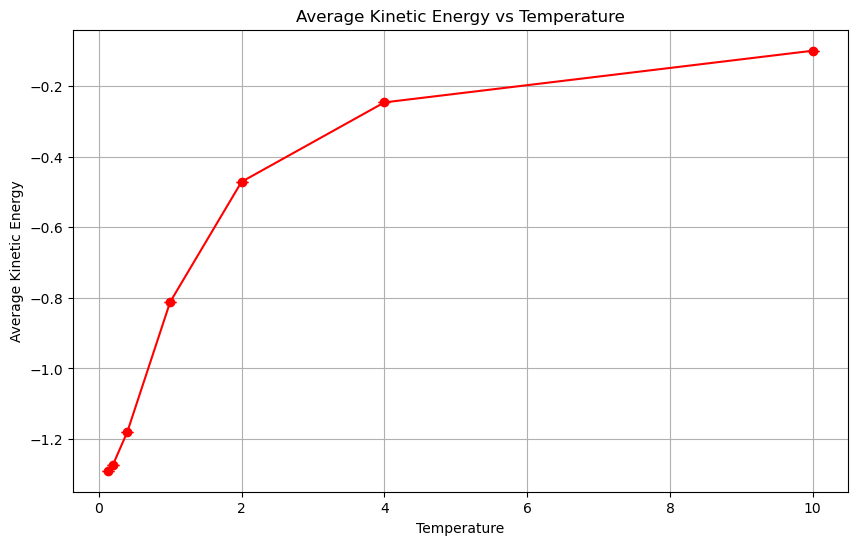

In [24]:
# Keep dt fixed to maintain a constant, small Trotter error
dt = 0.05 
L_tau_values = [150, 100, 50, 20, 10, 5, 2] # Sweeping from low to high T
temperatures = []
avg_kinetic_energies = []
err_kinetic_energies = []

for L_tau_current in L_tau_values:
    alpha = np.arccosh(np.exp(U * dt / 2))
    exp_minus_dtau_T = setup_kinetic_energy(N_sites, t, dt) 
    S = init_auxiliary_field(N_sites, L_tau_current)
    G_up, G_dn = init_greens_functions(N_sites, L_tau_current, S, alpha, exp_minus_dtau_T)

    bound_B_matrix_func = lambda l, sigma, S_field: compute_B_matrix(l, sigma, S_field, alpha, exp_minus_dtau_T)

    density_data, double_occ_data, ke_data = run_dqmc_sweeps(
        N_sites, L_tau_current, S, alpha, t, G_up, G_dn, bound_B_matrix_func
    )

    T_current = 1.0 / (L_tau_current * dt)
    temperatures.append(T_current)
    avg_kinetic_energies.append(ke_data[0])
    err_kinetic_energies.append(ke_data[1])

plt.figure(figsize=(10, 6))

# Use errorbar instead of plot
plt.errorbar(temperatures, avg_kinetic_energies, yerr=err_kinetic_energies, marker='o', linestyle='-', capsize=4, color='r')

plt.title('Average Kinetic Energy vs Temperature')
plt.xlabel('Temperature')
plt.ylabel('Average Kinetic Energy')
plt.grid(True)
plt.show()

#### Theoretical Sanity Checks
We can rely on a few theoretical limits to verify our numerical results for the expected energy:

$$ \langle E \rangle = \sum_{\mathbf{k}} \epsilon_{\mathbf{k}} \langle n_{\mathbf{k}} \rangle = \sum_{\mathbf{k}} \frac{\epsilon_{\mathbf{k}}}{e^{\beta(\epsilon_{\mathbf{k}} - \mu)} + 1} $$

**Low-Temperature Limit:**
At low temperatures, thermal fluctuations merely smooth the Fermi-Dirac distribution slightly near the Fermi level. By applying the Sommerfeld expansion or some argument over the smoothing process (See [Steven H. Simon, The Oxford Solid State Basics](https://www-thphys.physics.ox.ac.uk/people/SteveSimon/book.html), Chapter 4), we find that the energy follows:

$$ \langle E(T) \rangle \approx E(0) + \gamma (k_B T)^2 g(\epsilon_F) $$

This theoretical limit perfectly captures the quadratic behaviour we observe near $T=0$.

**High-Temperature Limit:**
Unlike a continuum free electron gas, the 1D tight-binding model has a strictly bounded dispersion relation: $\epsilon_k = -2t \cos(ka)$. At extreme high temperatures where the thermal energy overwhelms the bandwidth ($k_B T \gg t$), the Fermi-Dirac distribution flattens into a uniform distribution across the entire Brillouin zone. Consequently, the positive and negative energy states cancel out, and the expectation approaches zero:

$$ \langle E \rangle \propto \sum_k -2t \cos(ka) = 0 $$

**Numerical Verification:**
To convince ourselves of these analytical limits, we can compute the energy via numerical integration for the tight-binding model. This requires a two-step process. First, we solve the particle conservation equation to find the exact chemical potential $\mu$ at a specific temperature:

$$ N = \int_{-\infty}^{\infty} g(\epsilon) \frac{1}{e^{\beta(\epsilon - \mu)} + 1} d\epsilon $$

Once $\mu(T)$ is determined, we substitute it back into the integral to compute the total expected energy:

$$ \langle E(T) \rangle = \int_{-\infty}^{\infty} \epsilon g(\epsilon) \frac{1}{e^{\beta(\epsilon - \mu)} + 1} d\epsilon $$


In [20]:
from scipy.optimize import bisect

def calculate_energy_vs_temperature(t=1.0, filling_fraction=0.5, num_k_points=5000):
    k_array = np.linspace(-np.pi, np.pi, num_k_points,endpoint=False)#setting lattice constant a=1
    epsilon_k = -2 * t * np.cos(k_array)

    temperatures = np.linspace(0.01, 10.0, 100)#avoiding T=0 to prevent division by zero
    energy_per_site = []
    
    def fermi_dirac(energy, mu, T):
        beta = 1.0 / T
        exponent = beta * (energy - mu)
        exponent = np.clip(exponent, -100, 100)# Clip the exponent to prevent np.exp() overflow at low T
        return 1.0 / (1.0 + np.exp(exponent))

    target_particles = filling_fraction * num_k_points
    
    def particle_difference(mu_guess, T):
        current_particles = np.sum(fermi_dirac(epsilon_k, mu_guess, T))
        return current_particles - target_particles

    for T in temperatures:
        # bisection search to find chemical potential mu_T that gives the correct filling
        mu_T = bisect(particle_difference, -4*t, 4*t, args=(T,))
        occupancies = fermi_dirac(epsilon_k, mu_T, T)
        total_energy = np.sum(epsilon_k * occupancies)
        # Normalise
        energy_per_site.append(total_energy / num_k_points)
        
    return temperatures, np.array(energy_per_site)

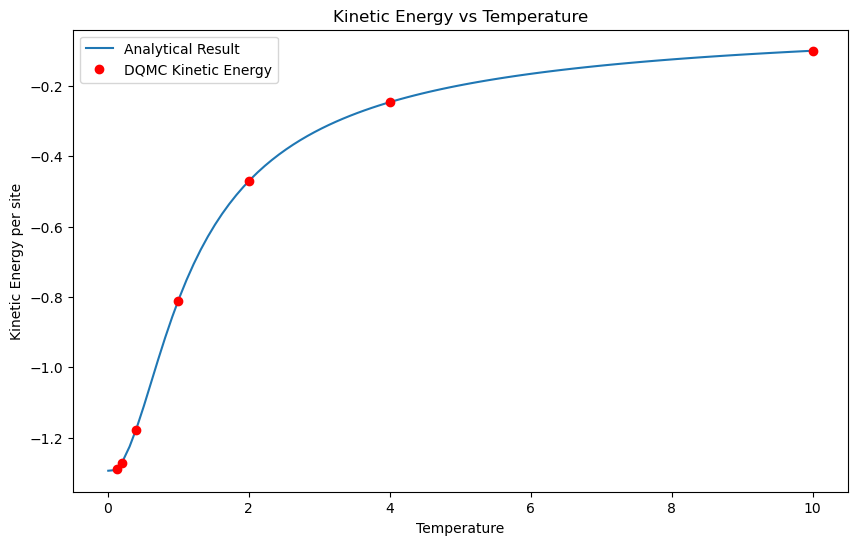

In [26]:
plt.figure(figsize=(10, 6))
T_vals, E_vals = calculate_energy_vs_temperature(t=1.0, filling_fraction=0.5, num_k_points=10)
plt.plot(T_vals, 2*E_vals, label='Analytical Result') #times 2 to account for spin degeneracy
plt.plot(temperatures, avg_kinetic_energies, label='DQMC Kinetic Energy', marker='o', color='red', linestyle='None')
plt.xlabel('Temperature')
plt.ylabel('Kinetic Energy per site')
plt.title('Kinetic Energy vs Temperature')
plt.legend()
plt.show()

### Atomic Limit t=0

In [18]:
# 1. Define Physical Parameters
N_sites = 10
L_tau = 200
delta_tau = 0.01
U = 1.0
t = 0.0

print(f"Temperature: {1.0 / (L_tau * delta_tau):.4f}")

# 2. System Initialisation
alpha = np.arccosh(np.exp(U * delta_tau / 2.0))
exp_minus_dtau_T = setup_kinetic_energy(N_sites, t, delta_tau)
S = init_auxiliary_field(N_sites, L_tau)
G_up, G_dn = init_greens_functions(N_sites, L_tau, S, alpha, exp_minus_dtau_T)

bound_B_matrix_func = lambda l, sigma, S_field: compute_B_matrix(l, sigma, S_field, alpha, exp_minus_dtau_T)

# Run the DQMC sweeps
avg_density, avg_double_occ, avg_kinetic_energy = run_dqmc_sweeps(N_sites, L_tau, S, alpha, t, G_up, G_dn, bound_B_matrix_func)
#print(f"Average Density: {avg_density:.4f}")
#print(f"Average Double Occupancy: {avg_double_occ:.4f}")
#print(f"Average Kinetic Energy: {avg_kinetic_energy:.4f}")

Temperature: 0.5000


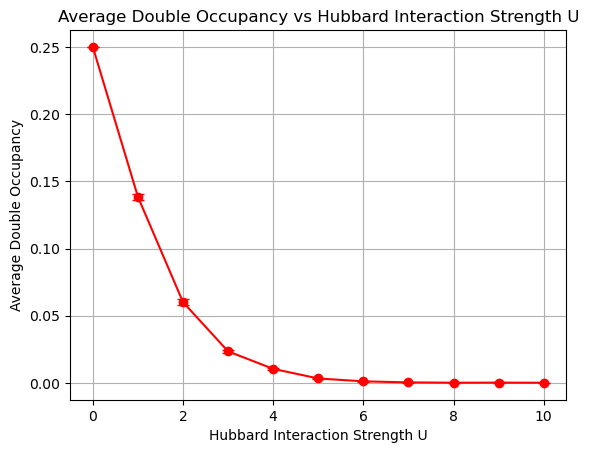

In [ ]:
Us = [0.0, 1.0, 2.0, 3.0, 4.0,5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
avg_double_occs = []
err_double_occs = []

for U in Us:
    #print(f"\nRunning DQMC for U = {U}")
    alpha = np.arccosh(np.exp(U * delta_tau / 2.0))
    exp_minus_dtau_T = setup_kinetic_energy(N_sites, t, delta_tau)
    S = init_auxiliary_field(N_sites, L_tau)
    G_up, G_dn = init_greens_functions(N_sites, L_tau, S, alpha, exp_minus_dtau_T)

    bound_B_matrix_func = lambda l, sigma, S_field: compute_B_matrix(l, sigma, S_field, alpha, exp_minus_dtau_T)

    avg_density, avg_double_occ, avg_kinetic_energy = run_dqmc_sweeps(N_sites, L_tau, S, alpha, t, G_up, G_dn, bound_B_matrix_func)

    #print(f"Average Double Occupancy: {avg_double_occ:.4f}")
    avg_double_occs.append(avg_double_occ[0])
    err_double_occs.append(avg_double_occ[1])  
plt.errorbar(Us, avg_double_occs, yerr=err_double_occs, marker='o', linestyle='-', capsize=4, color='r')
plt.title('Average Double Occupancy vs Hubbard Interaction Strength U')
plt.xlabel('Hubbard Interaction Strength U')
plt.ylabel('Average Double Occupancy')
plt.grid()
plt.show()

As interaction strength U increases, the average double occupancy decreases, indicating that electrons are less likely to occupy the same site due to stronger repulsion. This trend is consistent with the physical expectation that higher U values suppress double occupancy in the Hubbard model.

## U=1, t=1

In [ ]:
# 1. Define Physical Parameters

L_tau = 20
delta_tau = 0.001


print(f"Temperature: {1.0 / (L_tau * delta_tau):.4f}")

# 2. System Initialisation
alpha = np.arccosh(np.exp(U * delta_tau / 2.0))
exp_minus_dtau_T = setup_kinetic_energy(N_sites, t, delta_tau)
S = init_auxiliary_field(N_sites, L_tau)
G_up, G_dn = init_greens_functions(N_sites, L_tau, S, alpha, exp_minus_dtau_T)

bound_B_matrix_func = lambda l, sigma, S_field: compute_B_matrix(l, sigma, S_field, alpha, exp_minus_dtau_T)

Temperature: 50.0000


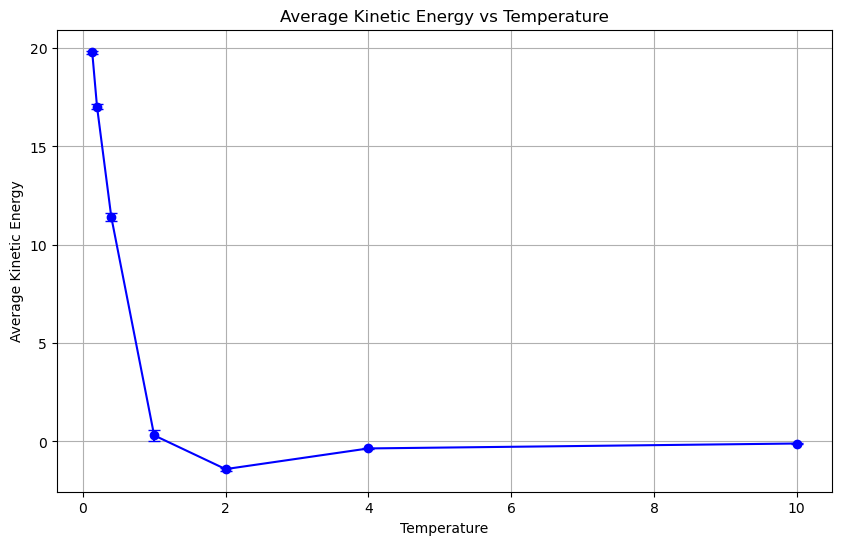

In [29]:
# Keep dt fixed to maintain a constant, small Trotter error
N_sites = 10
U = 1.0
t = 1.0
dt = 0.05 
L_tau_values = [150, 100, 50, 20, 10, 5, 2] # Sweeping from low to high T
temperatures = []
avg_kinetic_energies = []
err_kinetic_energies = []

alpha = np.arccosh(np.exp(U * dt / 2))
exp_minus_dtau_T = setup_kinetic_energy(N_sites, t, dt) 


for L_tau_current in L_tau_values:
    S = init_auxiliary_field(N_sites, L_tau_current)
    G_up, G_dn = init_greens_functions(N_sites, L_tau_current, S, alpha, exp_minus_dtau_T)

    bound_B_matrix_func = lambda l, sigma, S_field: compute_B_matrix(l, sigma, S_field, alpha, exp_minus_dtau_T)

    density_data, double_occ_data, ke_data = run_dqmc_sweeps(
        N_sites, L_tau_current, S, alpha, t, G_up, G_dn, bound_B_matrix_func
    )

    T_current = 1.0 / (L_tau_current * dt)
    temperatures.append(T_current)
    avg_kinetic_energies.append(ke_data[0])
    err_kinetic_energies.append(ke_data[1])

plt.figure(figsize=(10, 6))

# Use errorbar instead of plot
plt.errorbar(temperatures, avg_kinetic_energies, yerr=err_kinetic_energies, marker='o', linestyle='-', capsize=4, color='b')

plt.title('Average Kinetic Energy vs Temperature')
plt.xlabel('Temperature')
plt.ylabel('Average Kinetic Energy')
plt.grid(True)
plt.show()

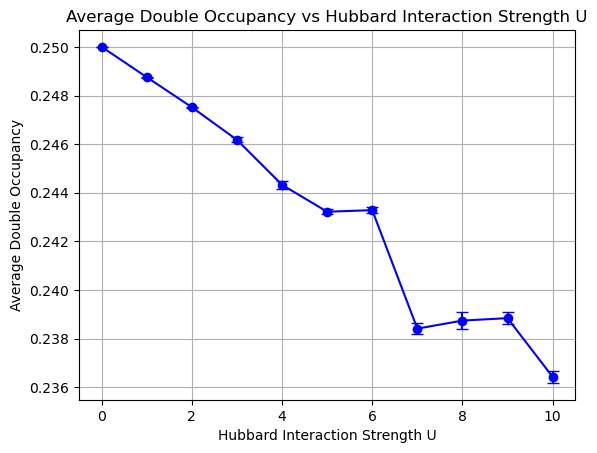

In [32]:
# Keep dt fixed to maintain a constant, small Trotter error
N_sites = 10
t = 1.0
dt = 0.05 
L_tau_values = 10 # Sweeping from low to high 
Us = [0.0, 1.0, 2.0, 3.0, 4.0,5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
avg_double_occs = []
err_double_occs = []

for U in Us:
    #print(f"\nRunning DQMC for U = {U}")
    alpha = np.arccosh(np.exp(U * delta_tau / 2.0))
    exp_minus_dtau_T = setup_kinetic_energy(N_sites, t, delta_tau)
    S = init_auxiliary_field(N_sites, L_tau)
    G_up, G_dn = init_greens_functions(N_sites, L_tau, S, alpha, exp_minus_dtau_T)

    bound_B_matrix_func = lambda l, sigma, S_field: compute_B_matrix(l, sigma, S_field, alpha, exp_minus_dtau_T)

    avg_density, avg_double_occ, avg_kinetic_energy = run_dqmc_sweeps(N_sites, L_tau, S, alpha, t, G_up, G_dn, bound_B_matrix_func)

    #print(f"Average Double Occupancy: {avg_double_occ:.4f}")
    avg_double_occs.append(avg_double_occ[0])
    err_double_occs.append(avg_double_occ[1])  # Example error bars

plt.errorbar(Us, avg_double_occs, yerr=err_double_occs, marker='o', linestyle='-', capsize=4, color='b')
plt.title('Average Double Occupancy vs Hubbard Interaction Strength U')
plt.xlabel('Hubbard Interaction Strength U')
plt.ylabel('Average Double Occupancy')
plt.grid()
plt.show()

## Appendix



### Theorem 1 **Sylvester's Determinant Identity**
$$\det(I_{m}+AB)=\det(I_{n}+BA)$$
Where $A$ is an $m \times n$ matrix, $B$ is an $n \times m$ matrix, and $I_{m}$ is an $m \times m$ identity matrix.
Proof:
$$\begin{aligned}
&\left|I_{m}+A B\right|=\left|\begin{array}{cc}
I_{m}+A B & 0 \\
B & I_{n}
\end{array}\right|=\left|\begin{array}{ccc}
I_{m} & -A \\
0 & I_{n}
\end{array}\right|\left|\begin{array}{ccc}
I_{m}+A B & 0 \\
B & I_{n}
\end{array}\right|\\
&=\left|\begin{array}{cc}
I_{m} & -A \\
B & I_{n}
\end{array}\right|=\left|\begin{array}{cc}
I_{m} & 0 \\
-B & I_{n}
\end{array}\right|\left|\begin{array}{cc}
I_{m} & -A \\
B & I_{n}
\end{array}\right|=\left|\begin{array}{cc}
I_{m} & -A \\
0 & I_{n}+B A
\end{array}\right|\\
&=\left|I_{n}+B A\right|
\end{aligned}$$



### Theorem 2 **Sherman-Morrison Formula**

$$(\mathbf{A}+\mathbf{U V})^{-1}=\mathbf{A}^{-1}-\mathbf{A}^{-1} \mathbf{U}\left(\mathbf{I}_{k}+\mathbf{V A^{-1} U}\right)^{-1} \mathbf{V}\mathbf{A}^{-1}$$
Where $\mathbf{A}$ is an $N \times N$ matrix, $\mathbf{U}$ is an $N \times k$ matrix, and $\mathbf{V}$ is a $k \times N$ matrix.


Proof:
Let $\xi=\mathbf{V} x$ and we have $\left(\mathbf{A}+\mathbf{U V}\right) x=b$, where $x$ and $b$ are $N \times 1$ vectors, and $\xi$ is a $k \times 1$ vector.
Write down the following form: $\left(\mathbf{A}+\mathbf{U V}\right) x=b$:
$$\left[\begin{array}{cc}
\mathbf{A} & \mathbf{U} \\
\mathbf{V} & -\mathbf{I_{k}}
\end{array}\right]\left[\begin{array}{l}
x \\
\xi
\end{array}\right]=\left[\begin{array}{l}
b \\
0
\end{array}\right]$$
Perform decomposition:
$$\left[\begin{array}{cc}
\mathbf{A} & \mathbf{U} \\
\mathbf{V} & -\mathbf{I_{k}}
\end{array}\right]=\left[\begin{array}{cc}
\mathbf{I_{N}} & 0 \\
\mathbf{V} \mathbf{A}^{-1} & \mathbf{I_{k}}
\end{array}\right]\left[\begin{array}{cc}
\mathbf{A} & \mathbf{U} \\
0 & -\mathbf{I_{k}}-\mathbf{V} \mathbf{A}^{-1} \mathbf{U}
\end{array}\right]$$
Utilising
$$\left[\begin{array}{cc}
\mathbf{I_{N}} & 0 \\
\mathbf{B} & \mathbf{I_{k}}
\end{array}\right]^{-1}=\left[\begin{array}{cc}
\mathbf{I_{N}} & 0 \\
-\mathbf{B} & \mathbf{I_{k}}
\end{array}\right]$$
$$\left[\begin{array}{cc}
\mathbf{A} & \mathbf{U} \\
0 & -\mathbf{I_{k}}-\mathbf{V} \mathbf{A}^{-1} \mathbf{U}
\end{array}\right]\left[\begin{array}{l}
x \\
\xi
\end{array}\right]=\left[\begin{array}{cc}
\mathbf{I_{N}} & 0 \\
-\mathbf{V} \mathbf{A}^{-1} & \mathbf{I_{k}}
\end{array}\right]\left[\begin{array}{l}
b \\
0
\end{array}\right]$$
We have:
$$\mathbf{A}x+\mathbf{U}\xi=b \qquad \left(-\mathbf{I_{k}}-\mathbf{V} \mathbf{A}^{-1} \mathbf{U}\right)\xi =-\mathbf{V} \mathbf{A}^{-1}b$$
Then:
$$x=\mathbf{A}^{-1} \left(b-\mathbf{U}\xi\right) \qquad \xi =-\left(-\mathbf{I_{k}}-\mathbf{V} \mathbf{A}^{-1} \mathbf{U}\right)^{-1}\mathbf{V} \mathbf{A}^{-1}b$$
Then:
$$x=\left[\mathbf{A}^{-1}-\mathbf{A}^{-1} \mathbf{U}\left(\mathbf{I}_{k}+\mathbf{V A^{-1} U}\right)^{-1} \mathbf{V}\mathbf{A}^{-1}\right]b$$
Or:
$$(\mathbf{A}+\mathbf{U V})^{-1}=\mathbf{A}^{-1}-\mathbf{A}^{-1} \mathbf{U}\left(\mathbf{I}_{k}+\mathbf{V A^{-1} U}\right)^{-1} \mathbf{V}\mathbf{A}^{-1}$$
as $\left(\mathbf{A}+\mathbf{U V}\right) x=b$.

Lastly, simply let $\mathbf{A}=\mathbf{I_N}$, which gives:
$$(\mathbf{I}+\mathbf{U V})^{-1}=\mathbf{I}-\mathbf{U}\left(\mathbf{I}_{k}+\mathbf{V U}\right)^{-1} \mathbf{V}$$